In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [23]:
sess = u.load_single_day(ko_mice[0],5)

{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 6}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.1/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_003.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.1/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_003.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


In [24]:
ttype = 'fam'
sess.field_perm_masks['sig_bins'][ttype].shape

(30, 771)

In [25]:
# num fields

# append false row, so that left edges find all fields, including those that start at the beinning of track
sig_bins = sess.field_perm_masks['sig_bins'][ttype]
_sig_bins = np.zeros((sig_bins.shape[0]+1, sig_bins.shape[1]))==1
_sig_bins[1:,:] = sig_bins

left_edges = 1*(_sig_bins[:-1,:]>_sig_bins[1:,:])
n_fields = left_edges.sum(axis=0)

# for each cell
# 

(array([191.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   7.]),
 array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ]),
 <BarContainer object of 10 artists>)

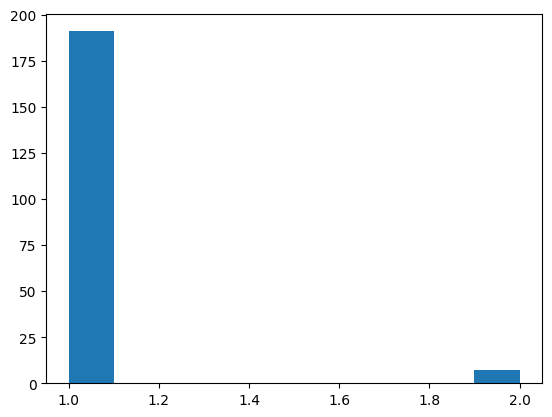

In [27]:
fig, ax = plt.subplots()
ax.hist(n_fields[n_fields>0])